# Pneumonia Detection from Chest X-rays — Google Colab workflow

This notebook is the recommended entry point for the project. It trains a compact CNN on the repository dataset, reports clinically relevant classification metrics, saves a portable Keras model, and includes an optional Gradio demo.

> Educational project only. This model is not a clinical diagnostic tool and must not be used for medical decisions.

## 1. Runtime and repository setup

In Colab, the next cell clones the repository if its dataset is not already available. The repository contains the image dataset, so the clone can take a few minutes and requires substantial storage. A GPU runtime is recommended: **Runtime → Change runtime type → T4 GPU**.

In [4]:
from pathlib import Path
import os
import random
import subprocess
import sys

REPO_URL = "https://github.com/kartikverma23/Major.git"

# Reuse the current directory when this notebook is run from a checked-out clone;
# otherwise clone the repository into Colab's writable filesystem.
def has_dataset(root: Path) -> bool:
    return any((root / "chest-xray-pneumonia" / "chest_xray" / suffix).is_dir()
               for suffix in ["chest_xray", "train"])

candidate_roots = [Path.cwd(), Path("/content/Major"), Path("/content")]
repo_dir = next((p for p in candidate_roots if has_dataset(p)), None)

if repo_dir is None:
    repo_dir = Path("/content/Major")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo_dir)], check=True)

print(f"Repository: {repo_dir.resolve()}")
print(f"Python: {sys.version.split()[0]}")

Repository: /content/Major
Python: 3.13.15


In [5]:
# TensorFlow is preinstalled in standard Colab runtimes. Install only if needed.
try:
    import tensorflow as tf
except ModuleNotFoundError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tensorflow"], check=True)
    import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: []


## 2. Locate and validate the dataset

The repository stores the dataset at `chest-xray-pneumonia/chest_xray/chest_xray/`, with `train`, `val`, and `test` splits and `NORMAL`/`PNEUMONIA` class folders.

In [6]:
DATASET_CANDIDATES = [
    repo_dir / "chest-xray-pneumonia" / "chest_xray" / "chest_xray",
    repo_dir / "chest-xray-pneumonia" / "chest_xray",
]
DATASET_ROOT = next(
    (p for p in DATASET_CANDIDATES if all((p / split).is_dir() for split in ["train", "val", "test"])),
    None,
)
if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Dataset root not found. Expected train/val/test under "
        "chest-xray-pneumonia/chest_xray/chest_xray."
    )

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
for split in ["train", "val", "test"]:
    counts = {
        name: sum(1 for p in (DATASET_ROOT / split / name).iterdir()
                  if p.is_file() and not p.name.startswith("._") and p.suffix.lower() in {".jpeg", ".jpg", ".png"})
        for name in CLASS_NAMES
    }
    print(f"{split}: {counts}")
print("Dataset root:", DATASET_ROOT)

train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
val: {'NORMAL': 8, 'PNEUMONIA': 8}
test: {'NORMAL': 234, 'PNEUMONIA': 390}
Dataset root: /content/Major/chest-xray-pneumonia/chest_xray/chest_xray


In [7]:
IMAGE_SIZE = (180, 180)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

common_args = dict(
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    seed=SEED,
)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "train", shuffle=True, **common_args
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "val", shuffle=False, **common_args
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "test", shuffle=False, **common_args
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


## 3. Inspect examples and define class weights

The dataset is imbalanced, so the model uses class weights and reports precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

/tmp/ipykernel_499/183673857.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASS_NAMES[int(labels[i].numpy())])


Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


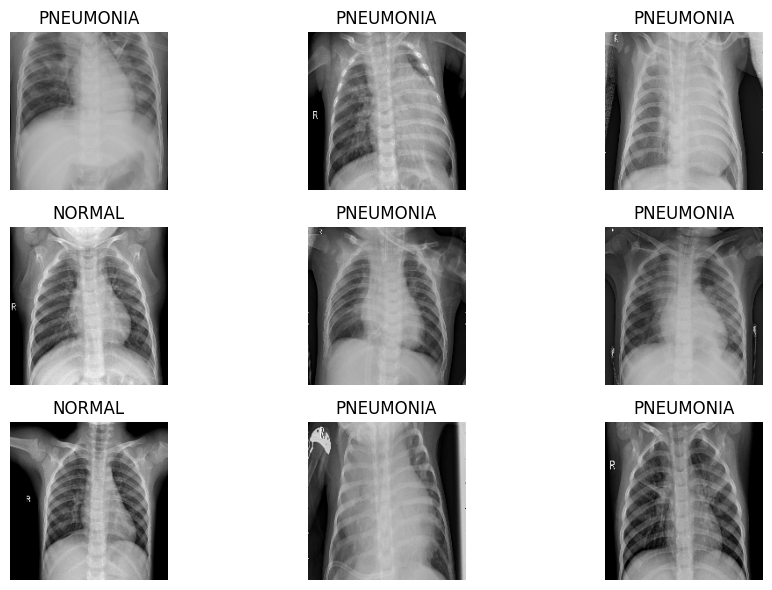

In [8]:
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i].numpy())])
        plt.axis("off")
plt.tight_layout()

counts = {}
for index, name in enumerate(CLASS_NAMES):
    counts[index] = sum(
        1 for p in (DATASET_ROOT / "train" / name).iterdir()
        if p.is_file() and not p.name.startswith("._") and p.suffix.lower() in {".jpeg", ".jpg", ".png"}
    )
total = sum(counts.values())
class_weight = {index: total / (len(CLASS_NAMES) * count) for index, count in counts.items()}
print("Class weights:", class_weight)

## 4. Build and train a reproducible baseline CNN

The default run is intentionally modest so it can complete in Colab. Increase `EPOCHS` after confirming the pipeline works.

In [9]:
EPOCHS = 5

augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.10),
], name="augmentation")

inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
x = augmentation(inputs)
x = keras.layers.Rescaling(1.0 / 255)(x)
for filters in [32, 64, 128]:
    x = keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.4)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="pneumonia_cnn")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)
model.summary()

Model: "pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=2, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 416s 3s/step - accuracy: 0.8464 - auc: 0.9273 - loss: 0.3352 - precision: 0.9627 - recall: 0.8253 - val_accuracy: 0.5000 - val_auc: 0.8359 - val_loss: 2.0567 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8826 - auc: 0.9506 - loss: 0.2681 - precision: 0.9766 - recall: 0.8611
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.8861 - auc: 0.9526 - loss: 0.2637 - precision: 0.9776 - recall: 0.8666 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 4.6852 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9022 - auc: 0.9659 - loss: 0.2286 - precision: 0.9795 - recall: 0.8870 - val_accuracy: 0.5000 - val_auc: 0.7969 - val_loss: 1.6844 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 3.0000e-

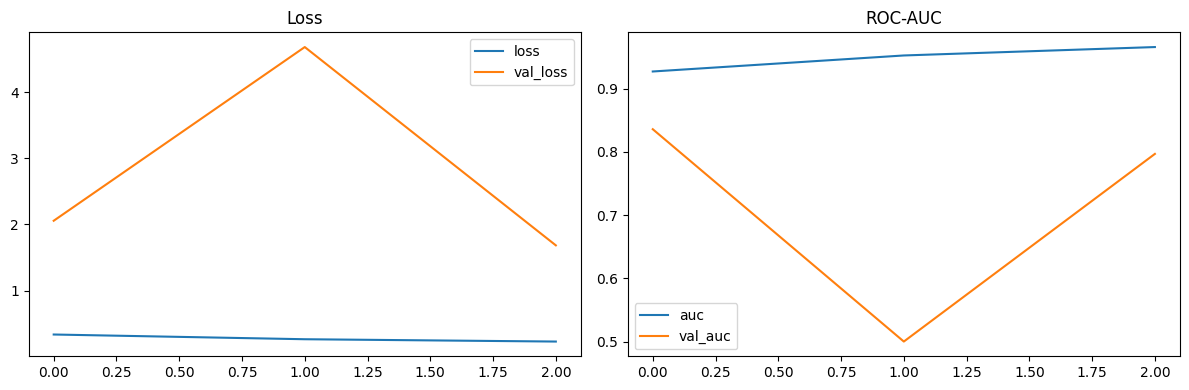

In [11]:
history_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Loss")
history_df[["auc", "val_auc"]].plot(ax=axes[1], title="ROC-AUC")
plt.tight_layout()

## 5. Evaluate on the held-out test set

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 481ms/step - accuracy: 0.6250 - auc: 0.7982 - loss: 1.5540 - precision: 0.6250 - recall: 1.0000
accuracy     0.6250
auc          0.7982
loss         1.5540
precision    0.6250
recall       1.0000
dtype: float64
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 501ms/step
              precision    recall  f1-score   support

      NORMAL     0.0000    0.0000    0.0000       234
   PNEUMONIA     0.6250    1.0000    0.7692       390

    accuracy                         0.6250       624
   macro avg     0.3125    0.5000    0.3846       624
weighted avg     0.3906    0.6250    0.4808       624

ROC-AUC: 0.8252


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


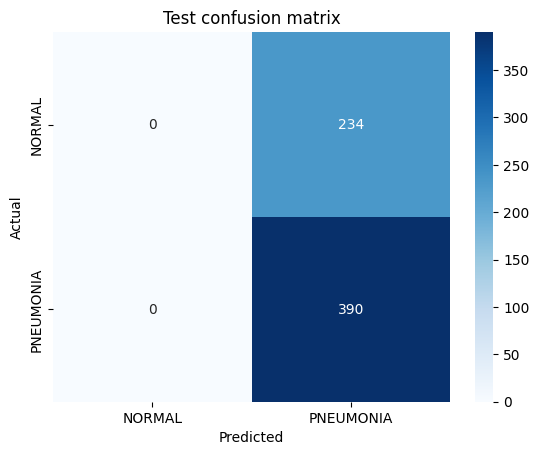

In [12]:
metrics = model.evaluate(test_ds, return_dict=True, verbose=1)
print(pd.Series(metrics).round(4))

y_true = np.concatenate([labels.numpy().reshape(-1) for _, labels in test_ds]).astype(int)
y_prob = model.predict(test_ds, verbose=1).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 4))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test confusion matrix")
plt.show()

In [13]:
ARTIFACT_DIR = repo_dir / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_PATH = ARTIFACT_DIR / "pneumonia_cnn.keras"
model.save(MODEL_PATH)
print(f"Saved model to: {MODEL_PATH}")

Saved model to: /content/Major/artifacts/pneumonia_cnn.keras


## 6. Optional single-image prediction

In [14]:
def predict_image(path):
    image = keras.utils.load_img(path, target_size=IMAGE_SIZE, color_mode="rgb")
    array = keras.utils.img_to_array(image)
    probability = float(model.predict(np.expand_dims(array, 0), verbose=0)[0][0])
    label = CLASS_NAMES[int(probability >= 0.5)]
    return {"label": label, "pneumonia_probability": round(probability, 4)}

# Example:
# predict_image(DATASET_ROOT / "test" / "NORMAL" / "<filename>.jpeg")

## 7. Optional Gradio demo

Leave `LAUNCH_GRADIO = False` for a notebook-only run. Set it to `True` after training to create a shareable public demo link. Do not use the demo for medical decisions.

In [15]:
LAUNCH_GRADIO = False
if LAUNCH_GRADIO:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gradio"], check=True)
    import gradio as gr

    def classify_upload(image):
        if image is None:
            return None
        image = image.convert("RGB").resize(IMAGE_SIZE)
        array = np.asarray(image, dtype="float32")
        probability = float(model.predict(np.expand_dims(array, 0), verbose=0)[0][0])
        return {CLASS_NAMES[0]: 1 - probability, CLASS_NAMES[1]: probability}

    demo = gr.Interface(
        fn=classify_upload,
        inputs=gr.Image(type="pil"),
        outputs=gr.Label(num_top_classes=2),
        title="Educational Pneumonia Classifier",
        description="Research/education demo only; not a medical diagnostic tool.",
    )
    demo.launch(share=True)